# Group AJ - Coursework ECS7026P - Neural Networks and Deep Learning
## **Zuveir Jameer (ID: 240903947)**
Daniel Ikenga (ID: 250751183) , Saman Zobeiry (ID: 160511183)

**2 May 2026**


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import time
import matplotlib.pyplot as plt

In [ ]:
# The standard CIFAR-10 training augmentation pipeline
train_transform = transforms.Compose([
    # Step A: Pad the image by 4 pixels then take a random 32x32 crop.
    # This simulates the object being in different positions.
    transforms.RandomCrop(32, padding=4),

    # Step B: Flip the image horizontally with a 50% chance.
    # A car facing left is still a car.
    transforms.RandomHorizontalFlip(p=0.5),

    # Step C: slight rotation (CIFAR-10 is small, so keep it subtle)
    # This did not help and therefore commented out
    # transforms.RandomRotation(15),

    # Also I tried jitter, but this reduced the train accuracy.

    # Step D: Convert to PyTorch Tensor
    transforms.ToTensor(),

    # Step E: Normalize with CIFAR-10 specific Mean and Std Dev
    # These constants are calculated across the entire dataset.
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Test transform should NOT have random crops or flips
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# -----------------------------
# 2. Load Datasets
# -----------------------------

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


100%|██████████| 170M/170M [00:04<00:00, 42.4MB/s]


1. Code and comments by Zuveir

2. Explained the differences between the base model and this model

3. Explained the results and what changes to the base model improves the performance

4. A few of the later experiments that I ran. Other notebooks with the experiments can be found here https://github.com/martian786/cifar

# Final code with comments for part 1
CIFAR-10 image classification

Epoch   1/50 | LR: 0.04995 | Train Loss: 1.7261 | Train Acc: 42.22% | Test Loss: 1.4224 | Test Acc: 57.93% | Best: 57.93% | Epoch Time: 75.8s | Total Time: 1.3m
Epoch   2/50 | LR: 0.04980 | Train Loss: 1.4477 | Train Acc: 57.31% | Test Loss: 1.2875 | Test Acc: 64.20% | Best: 64.20% | Epoch Time: 75.0s | Total Time: 2.5m
Epoch   3/50 | LR: 0.04956 | Train Loss: 1.3102 | Train Acc: 64.27% | Test Loss: 1.1787 | Test Acc: 70.11% | Best: 70.11% | Epoch Time: 74.9s | Total Time: 3.8m
Epoch   4/50 | LR: 0.04921 | Train Loss: 1.2202 | Train Acc: 68.72% | Test Loss: 1.1114 | Test Acc: 72.93% | Best: 72.93% | Epoch Time: 74.6s | Total Time: 5.0m
Epoch   5/50 | LR: 0.04878 | Train Loss: 1.1436 | Train Acc: 72.66% | Test Loss: 1.0284 | Test Acc: 77.61% | Best: 77.61% | Epoch Time: 75.0s | Total Time: 6.3m
Epoch   6/50 | LR: 0.04824 | Train Loss: 1.0892 | Train Acc: 75.38% | Test Loss: 1.0176 | Test Acc: 78.03% | Best: 78.03% | Epoch Time: 75.0s | Total Time: 7.5m
Epoch   7/50 | LR: 0.04762 | Train

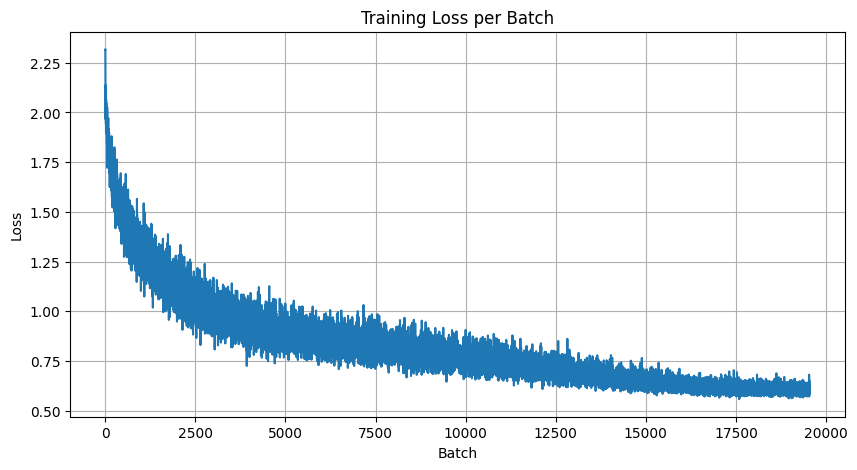

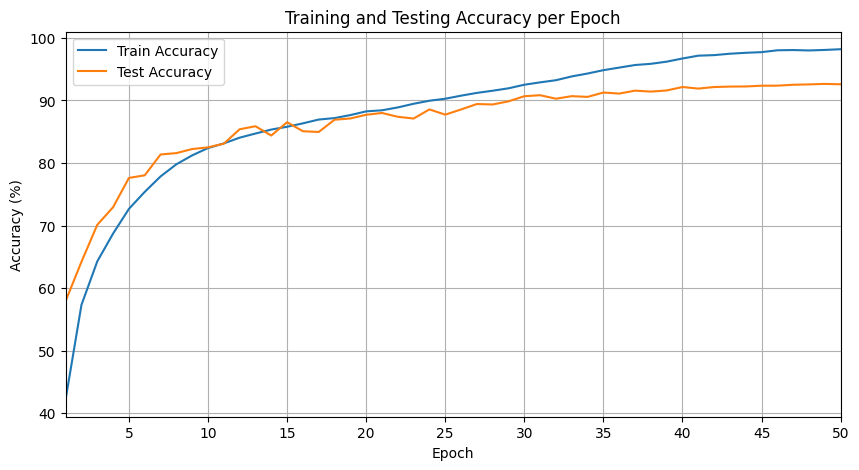

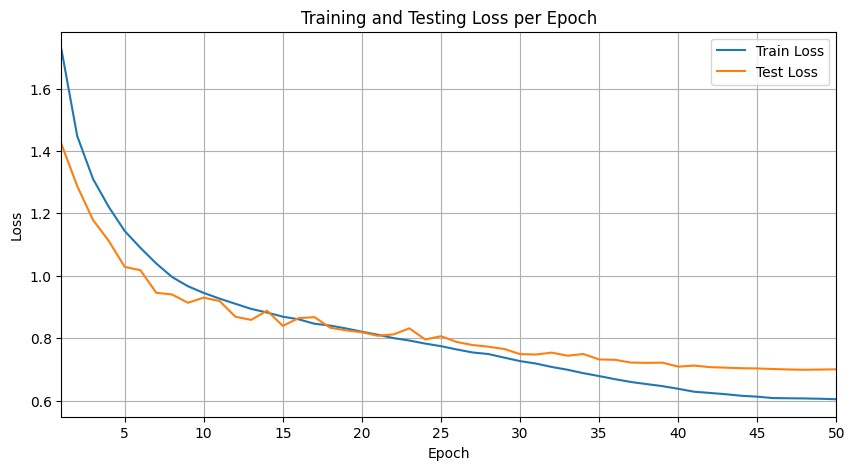

Model weights saved to no skip final_AdaptiveKernelNet_weights.pth
Last epoch data saved to no_skip_last_epoch_output.json


In [ ]:
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes, use_pool=False):
        super().__init__()

        self.branches = nn.ModuleList([
            nn.Sequential(
                # One convolutional branch per kernel size k. Each branch learns different
                # spatial features. Small kernels (3×3), k=3, captures fine detail like edges,
                # large kernels (5×5), k=5, captures broader patterns like shapes and textures.
                # both kernels lets the network decide which scale of feature matters most
                # for each input at runtime and not at design time.

                # bias=False because BatchNorm already learns a bias term (beta),
                # A conv bias would be redundant and waste parameters.
                nn.Conv2d(in_channels, out_channels, kernel_size=k, padding=k // 2, bias=False),

                # Normalises the output of the convolution branch before fusion, can improve convergence.
                # This helps stabilise training, ensures no single branch dominiates just because of raw values are larger
                nn.BatchNorm2d(out_channels)
            ) for k in kernel_sizes
        ])

        # Dropout2d zeros entire channels because neighbouring pixels in a feature map
        # are highly correlated. Dropping individual pixels has little effect.
        # Dropping whole channels forces the network to not rely on any single
        # feature map, which reduces overfitting. 10% and 15% was tested. I settled on
        # 10% after tests. 15% reduced the train accuracy by about 2%. 10% is enough
        # to regularise without discarding too much useful spatial information.
        self.dropout = nn.Dropout2d(0.1)

        # After the branch outputs are combined by the gating network, the weighted
        # sum can have an arbitrary scale and distribution. post_bn re-centres and
        # re-scales the fused output. This allows the next block to receive clean, normalised
        # input. This is important because the skip connection I experimented with was removed
        # The skip connection which previously helped stabilise the signal passing through,
        # was removed and lead to instabilities.
        self.post_bn = nn.BatchNorm2d(out_channels)

        # The Linear Layer (Gating Network) learns to route each input to the right kernel size.
        # It takes the channel average of x (a summary of what features are present)
        # and outputs one weight per branch. The kernel mix is input-dependent
        # i.e a batch of sky images could weight the 5×5 branch more and a batch with fine
        # texture might weight 3×3 more. The network learns this automatically.
        # in_channels → len(kernel_sizes) is intentionally tiny (e.g. 64→2) so the gating network adds almost no parameters or compute.
        # 64: This represents the number of input features (channels). The network looks at 64 different feature descriptions of the image.
        # 2: This represents the number of choices (branches). The network outputs 2 values, which are typically passed through a Softmax function to create a probability distribution
        # By projecting from 64 directly to 2, the layer only requires 64*2=128 weights, which is very small.
        self.fc = nn.Linear(in_channels, len(kernel_sizes))

        # MaxPool2d(2) halves both height and width, reducing spatial resolution
        # while keeping the channel count the same. This forces the network to build
        # increasingly abstract representations as depth increases, and reduces the
        # compute cost of subsequent layers.

        # nn.Identity() is used when no pooling is needed (e.g. block1 see further below) so the forward pass code stays the same regardless.
        self.pool = nn.MaxPool2d(2) if use_pool else nn.Identity()

    def forward(self, x):

        # Computes branch weights. Collapses spatial dimensions to get a channel summary (mean) vector [batch, channels].
        # This gives the gating network a sense of what features are present in the
        # input without it needing to process the full spatial map thereby keeps it lightweight.
        m = x.mean(dim=(2, 3))
        a = self.fc(m)

        # I added Softmax to ensure the branch weights always sum to exactly 1.0.
        # Without this, the weighted sum could grow or shrink arbitrarily as the
        # fc weights change during training, making training unstable.
        # With softmax, the fusion is always a convex combination of the branches.
        # Prevents exploding gradients for high learning rates by bounding the weights, preventing them from becoming arbitrarily large.
        a = torch.softmax(a, dim=1)

        # Compute all branches in parallel then stack into one tensor so we can
        # do the weighted sum later(see 2 further code lines below) in a single vectorised operation rather than a loop.
        # Shape after stack: [batch, num_branches, out_channels, H, W]
        branch_outputs = torch.stack([branch(x) for branch in self.branches], dim=1)

        # a is currently [batch, num_branches]. Add three trailing dimensions
        # so it broadcasts correctly against branch_outputs [batch, num_branches, C, H, W].
        # Each branch output is scaled by its learned weight, then summed across
        # the branch dimension to produce a single fused feature map.
        a = a.view(a.size(0), a.size(1), 1, 1, 1)
        x_prime = (a * branch_outputs).sum(dim=1)

        # Stabilize combined output (compensating for skip connection removal, which was used in some experiments,
        # by stabilizing the weighted/normalized sum)
        # normalise before activation so ReLU sees a centred distribution
        # and doesn't disproportionately remove negative values.
        x_prime = self.post_bn(x_prime)

        # Introduce non-linearity so the network can learn complex functions.
        # Without it, stacking blocks would collapse to a single linear transformation.
        x_prime = torch.relu(x_prime)

        # applied after activation so we drop meaningful activations,
        # not pre-activation values that ReLU might zero anyway.
        x_prime = self.dropout(x_prime)

        # Downsample after all processing is done so we do not lose
        # spatial information before the block has finished learning from it.
        return self.pool(x_prime)



# ---- Output block ------
# averages each channel, then uses FC layers to output logits

class OutputBlock(nn.Module):
    def __init__(self, in_channels, num_classes=10, hidden_dims=None):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = []

        # Dynamically build classifier layers based on hidden_dims list.
        # e.g. hidden_dims=[128] gives: Linear→BN→ReLU→Dropout→Linear(logits)
        # This makes the block reusable where we can add more hidden layers just by
        # passing a longer list e.g [128,64], without changing any code.
        layers = []
        input_dim = in_channels

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))  # Normalise activations before ReLU. Keeps values in a sensible range so ReLU does not saturate or die.
            layers.append(nn.ReLU())

            # Randomly zero 30% of neurons during training, forcing the network to not rely on any single feature.
            # This reduces overfitting in the classifier head.
            layers.append(nn.Dropout(0.3))
            input_dim = hidden_dim

        # Final layer produces one raw score (logit) per class.
        # No softmax because CrossEntropyLoss applies it internally,and combining them into one operation is numerically more stable.
        layers.append(nn.Linear(input_dim, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        # x: [batch, c, h, w]
        # x is [Batch, Channels, Height, Width] i.e NCHW from the last conv block.
        # Average across spatial H and W dimension, indices 2 and 3, for each channel separately to get one value per channel.
        # This collapses spatial information and gives a fixed-size vector regardless of input
        # resolution, which the Linear layers require. Purpose is Global Average Pooling (GAP).
        m = x.mean(dim=(2, 3)) #The output shape becomes [Batch, Channels].
        logits = self.classifier(m) # m ready to be fed into a nn.Linear classifier, which requires inputs in the form [Batch, Features].
        return logits



# ----- Full network: combines several intermediate blocks and one output block. ------
class AdaptiveKernelNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Channels grow 3→64→128→256 across blocks. Wider channels allow the network
        # to learn more features at each stage. I do not pool in block1 because
        # CIFAR-10 images are already small (32×32). Pooling too early would
        # discard spatial detail before the network has had a chance to learn from it.

        # I did extensive experimentation on the kernel sizes e.g [1,3,5,7] and [3,5,7], [3,3,5] and [1,3,5] on the different blocks
        # Found [3,5] is the optimal setting. I also tried pooling on last layer.
        # Lessons learned:
        # block1 the model is looking for edges and lines therefore do not need to see the whole image to find an edge.
        # block4 the model is looking for objects and context. To recognize a "car," the model needs to see the wheels, the windows,
        # and the ground simultaneously. A larger kernel e.g(7x7) helps capture those spatial relationships between parts that are far apart.
        # For a 32x32 CIFAR-10, a 5x5 kernel in the last layer is already seeing almost the entire image where the receptive field of roughly 33x33.
        # Adding a 7x7 kernel would be overkill.
        # Receptive Field is determined by the largest kernel in the branch i.e 5x5
        self.block1 = IntermediateBlock(in_channels=3, out_channels=64, kernel_sizes=[3, 5], use_pool=False) #kernel:3x3, RF=1+(3-1)*1= 3x3; kernel:5x5, RF=1+(5-1)*1 = 5x5;
        self.block2 = IntermediateBlock(in_channels=64, out_channels=128, kernel_sizes=[3, 5], use_pool=True) #Kernel:3x3, RF=5+(3-1)*1= 7x7; Kernel:5x5, RF=5+(5-1)*1= 9x9;
        self.block3 = IntermediateBlock(in_channels=128, out_channels=256, kernel_sizes=[3, 5], use_pool=True) #Kernel:3x3, RF=7+(3-1)*2= 11x11; Kernel:5x5, RF=9+(5-1)*2= 17x17;
        self.block4 = IntermediateBlock(in_channels=256, out_channels=256, kernel_sizes=[3, 5], use_pool=True) #Kernel:3x3, RF=11+(3-1)*4= 19x19; Kernel:5x5, RF=17+(5-1)*4= 33x33.

        # After block4, spatial size is 32 → 16 → 8 → 4 (three halvings from pools)
        # I did not add another layer due to risk of increased overfitting
        # kept complexity of architecture low
        # 0.3 Dropout is providing a stable gradients. Another layer would most likely needed
        # a reduction in the Dropout to 0.2 so as not to drop too much information.
        self.output_block = OutputBlock(in_channels=256, num_classes=10, hidden_dims=[128])

    def forward(self, x):
        # Input size: 32x32 | RF: 1x1
        x = self.block1(x) # Size: 32x32 | Max RF: 5x5
        x = self.block2(x) # Size: 16x16 | Max RF: 9x9
        x = self.block3(x) # Size: 8x8  | Max RF: 17x17
        x = self.block4(x) # Size: 4x4  | Max RF: 33x33
        logits = self.output_block(x) # Final linear layers for classification
        return logits

# ----Train / test-----

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train() # sets model to training mode — enables dropout and tells BatchNorm to compute statistics from the current batch rather than stored running stats
    running_loss = 0.0
    correct = 0
    total = 0
    batch_losses = []

    for images, labels in loader:   # one batch at a time
        images = images.to(device, non_blocking=True) # Move to appropriate device. non_blocking=True allows the CPU continue work while data transfers to GPU
        labels = labels.to(device, non_blocking=True) # Move to appropriate device

        optimizer.zero_grad()       # Zeros the gradients that are stored in the model parameters
        outputs = model(images)     # Use the model to perform the computation. Forward pass which computes predictions as raw logits
        loss = criterion(outputs, labels) # Compute the loss based on the outputs and labels tensors
        loss.backward()             # backpropagation to compute the gradient of the loss l w.r.t the model parameters
        optimizer.step()            # update all parameters by one gradient descent step, Updates the model parameters based on the gradients stored in them.

        running_loss += loss.item() # Stores the loss for this batch. Could write as running_loss.append(float(l)); .item() converts the tensor to a plain Python float
        batch_losses.append(loss.item()) # store per-batch loss for the batch-level plot

        predictions = outputs.argmax(dim=1) # highest logit = predicted class
        total += labels.size(0)
        correct += (predictions == labels).sum().item()


    avg_loss = running_loss / len(loader) # average over batches, not images, so it is comparable across different batch sizes
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy, batch_losses


def evaluate(model, loader, criterion, device):
    model.eval()        # disables dropout (all neurons active) and switches BatchNorm to use the running mean/variance accumulated during training, not the current batch

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():   # tells PyTorch not to build the computation graph, saves memory and speeds up inference since we do not need gradients when we're not updating weights
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)   # forward pass through the network. Outputs are raw logits one score per class.

            # Track test loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)   #argmax picks the index (i.e the model's predicted class) of the highest score, . No need for softmax as does not change which class wins and just adds to computation.

            total += labels.size(0)   #Counts how many images processed.
            correct += (predictions == labels).sum().item()   #Compares predicted class vs true class for every image in the batch, counts how many match.


    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

#----- Run -----

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 50
model = AdaptiveKernelNet().to(device)

# CrossEntropyLoss combines log_softmax + negative log likelihood in one numerically stable operation.
# label_smoothing=0.1 means instead of training toward hard targets
# (0 or 1), the model trains toward 0.9 for the correct class and spreads 0.1 across
# the rest. This reduced overconfidence and could improve generalisation.
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Applies softmax internally as part of the loss calculation.

# Standard momentum computes the gradient then takes a step. Nesterov first takes the momentum step, then computes the gradient from that
# lookahead position. Helps converge faster and more stably.
# weight_decay=5e-4 adds an L2 penalty on large weights which discourages the model
# from relying too heavily on any single parameter, another form of regularisation.
optimizer = optim.SGD(model.parameters(),lr=0.05,momentum=0.9, weight_decay=5e-4, nesterov=True)

# Cosine annealing smoothly reduces LR from 0.05 to ~0 following a cosine curve.
# This means the LR drops quickly at first then slows near the end i.e large steps
# early when far from the optimum and very small steps late when fine-tuning near convergence.
# Fixes instability seen towards the end of the epoch.
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

best_acc = 0.0
best_epoch = 0
total_start = time.time()

# Store metrics for plotting later. Keeping everything in one dict makes it easy
# to add new metrics later without changing the plotting code structure.
history = {
    'batch_loss': [], # every individual batch loss. Shows training stability
    'train_loss': [], # epoch average. Shows overall learning trend
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'lr': []          # Added - useful to verify the scheduler is behaving as expected
}

for epoch in range(epochs):
    epoch_start = time.time()

    train_loss, train_acc, batch_losses = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)
    scheduler.step()  # advances the LR schedule by one epoch
    current_lr = optimizer.param_groups[0]['lr'] # read LR after stepping so the logged value reflects what the next epoch will use

    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start

    # Save weights only when test accuracy improves. This ensures the saved model
    # is the best generalising version, not just the most recently trained one.
    # Training longer can actually hurt test accuracy (overfitting), so best != last.

    if test_acc > best_acc:
        best_acc = test_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_AdaptiveKernelNet_weights.pth')

    # Store for graphs
    history['batch_loss'].extend(batch_losses)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    print(
        f"Epoch {epoch+1:>3}/{epochs} | "
        f"LR: {current_lr:.5f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}% | "
        f"Best: {best_acc:.2f}% | "
        f"Epoch Time: {epoch_time:.1f}s | "
        f"Total Time: {total_time/60:.1f}m"
    )

print(f"\nTraining complete. Best test accuracy: {best_acc:.2f}% at epoch {best_epoch}")

# ---Plots---
# Plot 1: training loss for each batch
plt.figure(figsize=(10, 5))
plt.plot(history['batch_loss'])
plt.title('Training Loss per Batch')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Plot 2: training accuracy and testing accuracy for each epoch
epoch_nums = range(1, len(history['train_acc']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_acc'], label='Train Accuracy')
plt.plot(epoch_nums, history['test_acc'], label='Test Accuracy')
plt.title('Training and Testing Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
# plt.xticks(list(epoch_nums))
plt.xticks(range(0, epochs+1, 5))
plt.xlim(1, len(history['train_acc']))
plt.show()

# Plot 3: training loss and testing loss for each epoch
plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_loss'], label='Train Loss')
plt.plot(epoch_nums, history['test_loss'], label='Test Loss')
plt.title('Training and Testing Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# plt.xticks(list(epoch_nums))
plt.xticks(range(0, epochs+1, 5))
plt.xlim(1, len(history['train_loss']))
plt.show()

# Save the model weights once training is finished
torch.save(model.state_dict(), 'Dropout_noskip_final_AdaptiveKernelNet_weights.pth')
print("Model weights saved to no skip Dropout_noskip_final_AdaptiveKernelNet_weights.pth")


# Save raw output of last epoch
last_epoch_data = {
    'train_loss': history['train_loss'][-1],
    'train_acc': history['train_acc'][-1],
    'test_loss': history['test_loss'][-1],
    'test_acc': history['test_acc'][-1],
    'lr': history['lr'][-1],
    'epoch': epochs
}

import json
with open('last_epoch_output.json', 'w') as f:
    json.dump(last_epoch_data, f, indent=4)

print("Last epoch data saved to last_epoch_output.json")

In [ ]:
print(model)

AdaptiveKernelNet(
  (block1): IntermediateBlock(
    (branches): ModuleList(
      (0): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): Sequential(
        (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (dropout): Dropout2d(p=0.1, inplace=False)
    (post_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc): Linear(in_features=3, out_features=2, bias=True)
    (pool): Identity()
  )
  (block2): IntermediateBlock(
    (branches): ModuleList(
      (0): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stat

In [ ]:
for name, param in model.named_parameters():
    print(name, param.shape)

block1.branches.0.0.weight torch.Size([64, 3, 3, 3])
block1.branches.0.1.weight torch.Size([64])
block1.branches.0.1.bias torch.Size([64])
block1.branches.1.0.weight torch.Size([64, 3, 5, 5])
block1.branches.1.1.weight torch.Size([64])
block1.branches.1.1.bias torch.Size([64])
block1.post_bn.weight torch.Size([64])
block1.post_bn.bias torch.Size([64])
block1.fc.weight torch.Size([2, 3])
block1.fc.bias torch.Size([2])
block2.branches.0.0.weight torch.Size([128, 64, 3, 3])
block2.branches.0.1.weight torch.Size([128])
block2.branches.0.1.bias torch.Size([128])
block2.branches.1.0.weight torch.Size([128, 64, 5, 5])
block2.branches.1.1.weight torch.Size([128])
block2.branches.1.1.bias torch.Size([128])
block2.post_bn.weight torch.Size([128])
block2.post_bn.bias torch.Size([128])
block2.fc.weight torch.Size([2, 64])
block2.fc.bias torch.Size([2])
block3.branches.0.0.weight torch.Size([256, 128, 3, 3])
block3.branches.0.1.weight torch.Size([256])
block3.branches.0.1.bias torch.Size([256])
blo

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params}")
print(f"Trainable params: {trainable_params}")

Total params: 3666968
Trainable params: 3666968


In [ ]:
from torchinfo import summary

summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
AdaptiveKernelNet                        [1, 10]                   --
├─IntermediateBlock: 1-1                 [1, 64, 32, 32]           --
│    └─Linear: 2-1                       [1, 2]                    8
│    └─ModuleList: 2-2                   --                        --
│    │    └─Sequential: 3-1              [1, 64, 32, 32]           1,856
│    │    └─Sequential: 3-2              [1, 64, 32, 32]           4,928
│    └─BatchNorm2d: 2-3                  [1, 64, 32, 32]           128
│    └─Dropout2d: 2-4                    [1, 64, 32, 32]           --
│    └─Identity: 2-5                     [1, 64, 32, 32]           --
├─IntermediateBlock: 1-2                 [1, 128, 16, 16]          --
│    └─Linear: 2-6                       [1, 2]                    130
│    └─ModuleList: 2-7                   --                        --
│    │    └─Sequential: 3-3              [1, 128, 32, 32]          73,984
│   

# Explanation of Code

## **Enhanced Neural Network Architecture**

The basic version is a simple adaptive multi-kernel CNN. It uses three intermediate blocks, each with parallel convolution branches, and combines them using learned weights.

The enhanced architecture (`AdaptiveKernelNet)` is a deeper and more regularised version of the basic adaptive-kernel CNN. It has the same main design as the basic model where each intermediate block contains multiple convolution branches, and a small gating network learns how much weight to give each branch for each input image. The enhanced model uses four intermediate blocks, wider channel sizes, BatchNorm, Softmax-based branch weighting, Dropout, MaxPooling, and a larger classifier head. During training, it uses label smoothing, SGD with momentum and Nesterov acceleration, weight decay, cosine learning-rate scheduling, data augmentation, and metric tracking.

## **Differences Between the Basic and Enhanced Architectures**

## 1. Model Structure

The number of intermediate blocks was increased from 3 to 4. The channel progression was changed from 3 → 32 → 64 → 128 in the basic version to 3 → 64 → 128 → 256 → 256 in the enhanced version. This means the final classifier input increased from 128 to 256 channels. The enhanced model is wider and deeper, hence has more capacity to learn complex image features.

**2. Kernel branches**

** The basic version had three branches per block with kernel sizes \[1, 3, 5\]. The enhanced version has two branches per block with kernel sizes \[3, 5\]. **The enhanced version removes the `1×1` branch and focuses on `3×3` and `5×5` kernels which are more useful for spatial feature extraction on CIFAR-10 images.

## 3. Convolution branch improvements

### Basic version

```
nn.Conv2d(in\_channels, out\_channels, kernel\_size=k, padding=k // 2)
```

In the basic version each branch is just a convolution. The enhanced version adds ba**tch normalisation **after each branch convolution. The convolution bias was disabled because BatchNorm includes a learnable shift parameter, making the convolution bias redundant when Conv2d is immediately followed by BatchNorm. These changes provided better training stability and reduced the risk of one branch dominating due to scale.

### Enhanced version

```
nn.Conv2d(..., bias=False)

nn.BatchNorm2d(out\_channels)
```

## 4. Gating / branch weighting

In the basic model, the branch weights are raw linear outputs, so they can be positive, negative, large, or small. This means the basic model learns an unconstrained weighted sum: x' = a1C1(x) + a2C2(x) + ... + aLCL(x). In the enhanced version, Softmax is applied to the branch weights, making them positive and forcing them to sum to 1. This makes the branch fusion more stable because the enhanced model learns a convex combination of branches.

```
m = x.mean(dim=(2, 3))

a = self.fc(m)

a = torch.softmax(a, dim=1) \# Added to enhanced version
```

## 5. Activation placement

In the basic version, ReLU was outside each block. In the enhanced version, ReLU is within the intermediate block. The enhanced block is more self-contained as it handles normalisation, activation, dropout, and optional pooling internally (BatchNorm → ReLU → Dropout → Pool).

Basic version:

```
x = self.block1(x)

x = torch.relu(x)
```

Enhanced version:

```
x_prime = self.post\_bn(x_prime)

x_prime = torch.relu(x_prime)

x_prime = self.dropout(x_prime)

return self.pool(x_prime)
```

## 6. Post-fusion BatchNorm

The enhanced version adds BatchNorm after the weighted sum. It normalises the fused output before passing it through ReLU. This helps stabilise the signal going into the next block given that skip connection was removed.

```
self.post_bn = nn.BatchNorm2d(out_channels)
```

## 7. Dropout

There was no Dropout in the basic version. The enhanced version has Dropout in convolutional blocks nn.Dropout2d(0.1) and inside the classifier nn.Dropout(0.3). This helps reduce overfitting given that the enhanced model is much larger than the basic model.

## 8. Pooling and spatial resolution

There was no Pooling in the basic version and the spatial size remains 32x32 throughout the network. The enhanced version uses MaxPool2d(2) in blocks 2, 3, and 4, reducing the spatial resolution from 32×32 to 16×16, then 8×8, and finally 4×4. This creates a more hierarchical feature representation, allowing later layers to learn more abstract features while reducing computation.

## 9. Output block / classifier

The hidden layer size was changed from 64 in the basic version to 128 in the enhanced version. The enhanced classifier is more robust because it uses BatchNorm and Dropout before the final classification layer (basic version Linear → ReLU → Linear; Enhanced version, Linear → BatchNorm1d → ReLU → Dropout → Linear).

##**Differences in Training Setup**

## 1. Loss function

The basic model trains using hard labels only. The enhanced version of CrossEntropyLoss() uses label smoothing which discourages the model from becoming too confident and can improve generalisation.

```
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
```

## 2. Optimiser


The basic version uses Adam with learning rate of 0.001. The enhanced version uses SGD with a learning rate of 0.05. It also uses momentum 0.9, weight decay 5e-4 and Nesterov momentum.

## 3. Learning-rate scheduling

Learning rate scheduling was not present in the basic version. I added CosineAnnealingLR scheduler which gradually reduces the learning rate over training thereby allowing larger updates early and finer updates later.

```
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
```

## 4. Number of epochs

The number of epochs was increased from 20 in the basic version to 50 in the enhanced version.

## 5. Evaluation function

The enhanced evaluation function uses the loss criterion during evaluation and returns both test loss and test accuracy. This is better for diagnosing overfitting because I can compare train loss and test loss.

## Practical impact

| Feature | Expected effect |
| :-: | :-: |
| More channels | More representational power |
| Extra block | Deeper feature hierarchy |
| BatchNorm | More stable training |
| Softmax gating | More stable branch weighting |
| Dropout | Less overfitting |
| MaxPooling | More abstract spatial features |
| Label smoothing | Less overconfident predictions |
| SGD + momentum | Often improves generalisation in CNN image classification tasks |
| Cosine LR scheduler | Smoother convergence |


##**Training Hyperparameters and Techniques**

1. Hyperparameters Used for Training: Batch size = 128, Training data augmentation = RandomCrop + RandomHorizontalFlip, Input normalisation = CIFAR-10 mean and standard deviation, num\_workers = 2, pin\_memory = True, shuffle = True for training, shuffle = False for testing.

    Epochs = `50, `Loss function = `CrossEntropyLoss, `Label smoothing = `0.1, `Optimiser = `SGD, `Learning rate = `0.05, `Momentum = `0.9, `Weight decay = `5e-4, `Nesterov momentum = `True, `LR scheduler = `CosineAnnealingLR, `Scheduler `T_max = 50, `Conv block dropout = `Dropout2d(0.1), `Classifier dropout = `Dropout(0.3), `BatchNorm in conv branches = `BatchNorm2d, `Post-fusion BatchNorm = `BatchNorm2d, `Classifier BatchNorm = `BatchNorm1d, `Kernel sizes = `[3, 5], `Number of adaptive branches = `2` per block, Pooling = `MaxPool2d(2)` in blocks 2, 3, and 4, Activation = `ReLU, `Final hidden layer size = `128, `Output classes = `10`


2. Dataset Preprocessing and Data Augmentation: The training set used RandomCrop(32, padding=4), RandomHorizontalFlip(p=0.5), ToTensor(), and CIFAR-10 normalisation. The test set used only ToTensor() and CIFAR-10 normalisation, with no random augmentation.**

3. Techniques Employed for Training: Data augmentation, random cropping, random horizontal flipping, CIFAR-10 input normalisation, mini-batch training, shuffled training batches, pinned-memory data loading, Batch Normalisation, Dropout regularisation, label smoothing, weight decay, SGD with momentum, Nesterov acceleration, cosine annealing learning-rate scheduling, model checkpointing, and metric tracking.**


# Example of Experiment - No Skip Connection + BatchNorm in intermediate block

Epoch   1/50 | LR: 0.05000 | Train Loss: 1.5506 | Train Acc: 51.43% | Test Loss: 1.4311 | Test Acc: 59.35% | Best: 59.35% | Epoch Time: 75.8s | Total Time: 1.3m
Epoch   2/50 | LR: 0.04995 | Train Loss: 1.2260 | Train Acc: 68.52% | Test Loss: 1.2646 | Test Acc: 66.94% | Best: 66.94% | Epoch Time: 75.2s | Total Time: 2.5m
Epoch   3/50 | LR: 0.04980 | Train Loss: 1.1089 | Train Acc: 74.55% | Test Loss: 1.3234 | Test Acc: 64.19% | Best: 66.94% | Epoch Time: 75.0s | Total Time: 3.8m
Epoch   4/50 | LR: 0.04956 | Train Loss: 1.0364 | Train Acc: 78.09% | Test Loss: 1.1218 | Test Acc: 74.32% | Best: 74.32% | Epoch Time: 74.9s | Total Time: 5.0m
Epoch   5/50 | LR: 0.04921 | Train Loss: 0.9847 | Train Acc: 80.51% | Test Loss: 1.0800 | Test Acc: 75.60% | Best: 75.60% | Epoch Time: 74.9s | Total Time: 6.3m
Epoch   6/50 | LR: 0.04878 | Train Loss: 0.9404 | Train Acc: 82.48% | Test Loss: 1.0205 | Test Acc: 77.57% | Best: 77.57% | Epoch Time: 74.6s | Total Time: 7.5m
Epoch   7/50 | LR: 0.04824 | Train

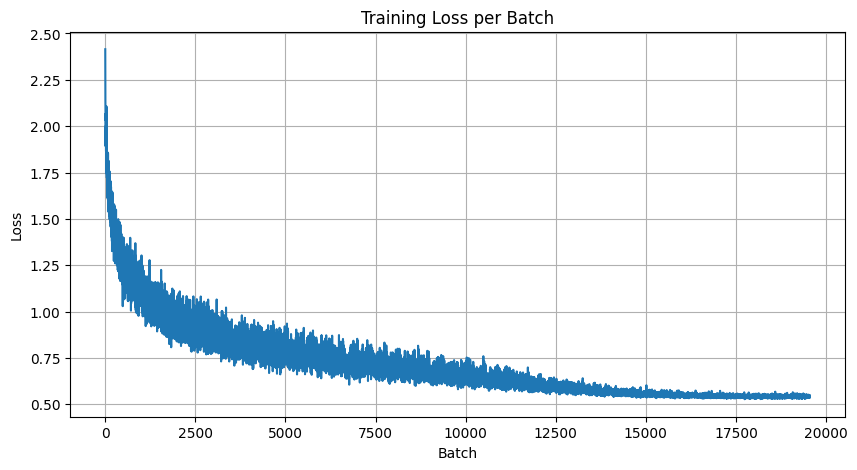

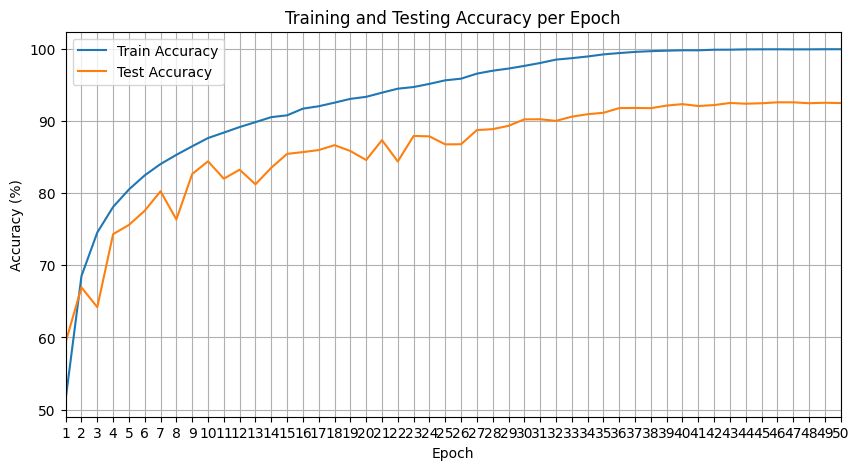

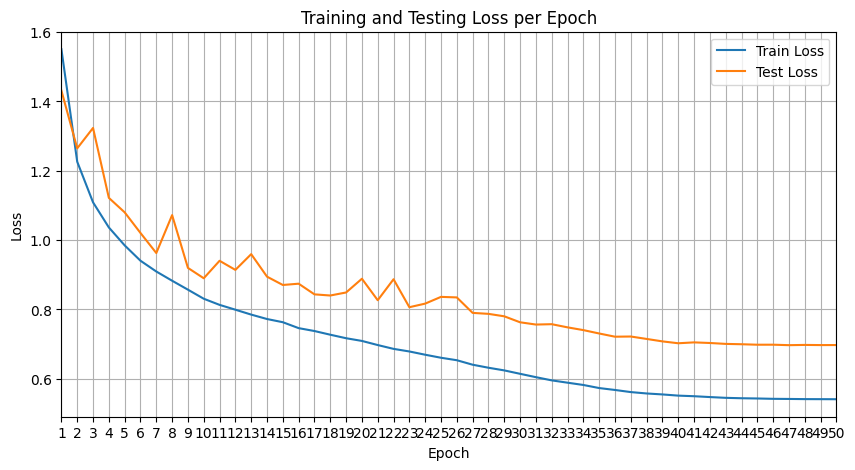

Model weights saved to final_AdaptiveKernelNet_weights.pth


In [ ]:
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes, use_pool=False):
        super().__init__()

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=k, padding=k // 2, bias=False),
                nn.BatchNorm2d(out_channels)
            ) for k in kernel_sizes
        ])

        # Skip Connection
        # if in_channels != out_channels:
        #     self.shortcut = nn.Sequential(
        #         nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
        #         nn.BatchNorm2d(out_channels)
        #     )
        # else:
        #     self.shortcut = nn.Identity()
        self.post_bn = nn.BatchNorm2d(out_channels)  #normalize after branch fusion
        self.fc = nn.Linear(in_channels, len(kernel_sizes))
        self.pool = nn.MaxPool2d(2) if use_pool else nn.Identity()

    def forward(self, x):
        # 1. Save the shortcut (identity or projected)
        # identity = self.shortcut(x)

        # 2. Compute branch weights
        m = x.mean(dim=(2, 3))
        a = self.fc(m)
        a = torch.softmax(a, dim=1) #Added 2 April. ensured the branch weights always sum to 1.0. Prevents exploding gradients for high learning rates.
        # 3. Compute weighted sum of branches
        branch_outputs = torch.stack([branch(x) for branch in self.branches], dim=1)
        a = a.view(a.size(0), a.size(1), 1, 1, 1)
        x_prime = (a * branch_outputs).sum(dim=1)

        # 4. Skip connection
        # allows the gradient to flow through the "shortcut" without being modified by the weights of the branches,
        # x_prime += identity
        x_prime = self.post_bn(x_prime) # 24 April Added. weighted sum normalized stabilize combined output because removed skip connection.
        x_prime = torch.relu(x_prime) #3 April Added

        return self.pool(x_prime)



# ---- Output block ------
# averages each channel, then uses FC layers to output logits

class OutputBlock(nn.Module):
    def __init__(self, in_channels, num_classes=10, hidden_dims=None):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = []

        layers = []
        input_dim = in_channels

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        # x: [batch, c, h, w]
        m = x.mean(dim=(2, 3))
        logits = self.classifier(m)
        return logits



# ----- Full network: combines several intermediate blocks and one output block. ------
class AdaptiveKernelNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = IntermediateBlock(in_channels=3, out_channels=64, kernel_sizes=[3, 5], use_pool=False)
        self.block2 = IntermediateBlock(in_channels=64, out_channels=128, kernel_sizes=[3, 5], use_pool=True)
        self.block3 = IntermediateBlock(in_channels=128, out_channels=256, kernel_sizes=[3, 5], use_pool=True)
        self.block4 = IntermediateBlock(in_channels=256, out_channels=256, kernel_sizes=[3, 5], use_pool=True)

        self.output_block = OutputBlock(in_channels=256, num_classes=10, hidden_dims=[128])

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        logits = self.output_block(x)
        return logits

# ----Train / test-----

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                   # Training mode
    running_loss = 0.0
    correct = 0
    total = 0
    batch_losses = []

    for images, labels in loader:   # one batch at a time
        images = images.to(device, non_blocking=True) # Move to appropriate device
        labels = labels.to(device, non_blocking=True) # Move to appropriate device

        optimizer.zero_grad()       # Zeros the gradients that are stored in the model parameters
        outputs = model(images)     # Use the model to perform the computation. Forward pass
        loss = criterion(outputs, labels) # Compute the loss based on the outputs and labels tensors
        loss.backward()             # backpropagation to compute the gradient of the loss l w.r.t the model parameters
        optimizer.step()            # Do one step of gradient descent, Updates the model parameters based on the gradients stored in them.

        running_loss += loss.item() # Stores the loss for this batch. Could write as running_loss.append(float(l)).
        batch_losses.append(loss.item())

        predictions = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()


    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy, batch_losses


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)   # forward pass through the network. Outputs are raw logits one score per class.

            # Track test loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)   #pick the index of the highest score, i.e the model's predicted class. No need for softmax as just adds to computation.

            total += labels.size(0)   #Counts how many images processed.
            correct += (predictions == labels).sum().item()   #Compares predicted class vs true class for every image in the batch, counts how many match.


    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

#----- Run ----- changed lr from 0.1 to 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 50
model = AdaptiveKernelNet().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Applies softmax internally as part of the loss calculation. 19th April added label_smoothing=0.1
optimizer = optim.SGD(model.parameters(),lr=0.05,momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) # added Cosine annealing smoothly reduces the LR following a cosine curve. Prevents LR being too large late in training and fixes instability seen towards the end of the epoch.

best_acc = 0.0
best_epoch = 0
total_start = time.time()

# Store history for plotting later
history = {
    'batch_loss': [],
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'lr': []
}

for epoch in range(epochs):
    epoch_start = time.time()

    train_loss, train_acc, batch_losses = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()

    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start

    if test_acc > best_acc:
        best_acc = test_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_AdaptiveKernelNet_weights.pth')

    # Store for graphs
    history['batch_loss'].extend(batch_losses)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    print(
        f"Epoch {epoch+1:>3}/{epochs} | "
        f"LR: {current_lr:.5f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}% | "
        f"Best: {best_acc:.2f}% | "
        f"Epoch Time: {epoch_time:.1f}s | "
        f"Total Time: {total_time/60:.1f}m"
    )

print(f"\nTraining complete. Best test accuracy: {best_acc:.2f}% at epoch {best_epoch}")

# ---Plots---
# Plot 1: training loss for each batch
plt.figure(figsize=(10, 5))
plt.plot(history['batch_loss'])
plt.title('Training Loss per Batch')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Plot 2: training accuracy and testing accuracy for each epoch
epoch_nums = range(1, len(history['train_acc']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_acc'], label='Train Accuracy')
plt.plot(epoch_nums, history['test_acc'], label='Test Accuracy')
plt.title('Training and Testing Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.xticks(list(epoch_nums))
plt.xlim(1, len(history['train_acc']))
plt.show()

# Plot 3: training loss and testing loss for each epoch
plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_loss'], label='Train Loss')
plt.plot(epoch_nums, history['test_loss'], label='Test Loss')
plt.title('Training and Testing Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(list(epoch_nums))
plt.xlim(1, len(history['train_loss']))
plt.show()

# Save the model weights once training is finished
torch.save(model.state_dict(), 'final_AdaptiveKernelNet_weights.pth')
print("Model weights saved to final_AdaptiveKernelNet_weights.pth")

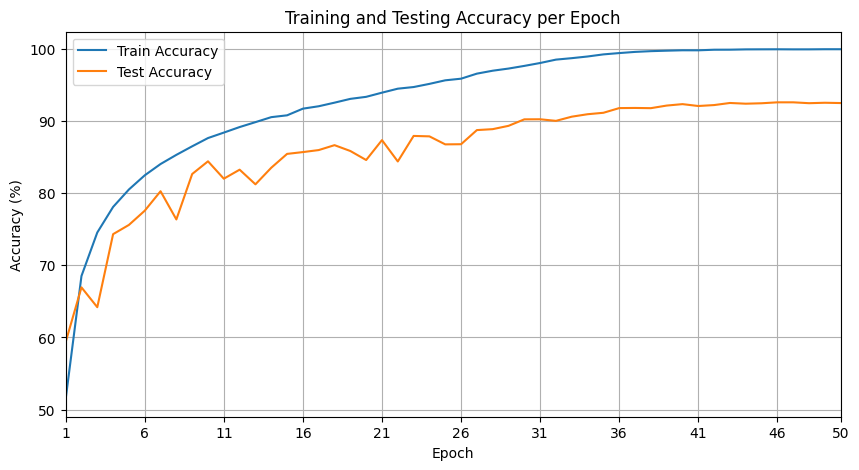

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_acc'], label='Train Accuracy')
plt.plot(epoch_nums, history['test_acc'], label='Test Accuracy')
plt.title('Training and Testing Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)

tick_positions = list(range(1, len(history['train_acc']), 5))
if len(history['train_acc']) not in tick_positions:
    tick_positions.append(len(history['train_acc']))

plt.xticks(tick_positions)
plt.xlim(1, len(history['train_acc']))
plt.show()

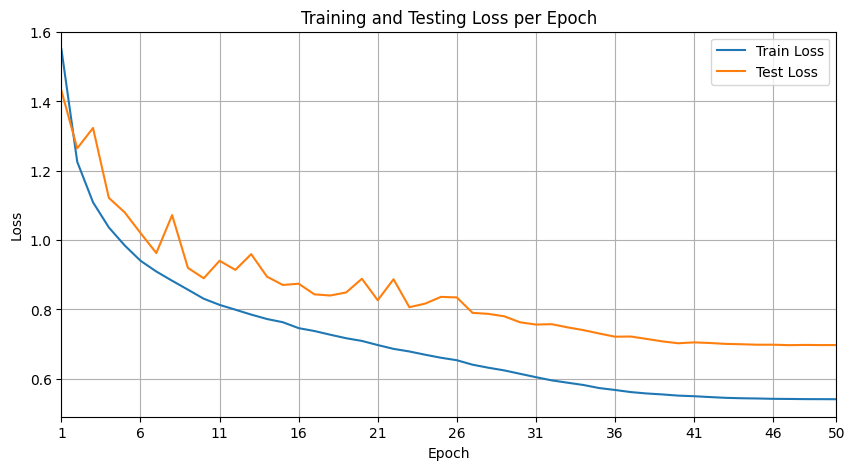

In [ ]:
# Plot 3: training loss and testing loss for each epoch
plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_loss'], label='Train Loss')
plt.plot(epoch_nums, history['test_loss'], label='Test Loss')
plt.title('Training and Testing Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

tick_positions = list(range(1, len(history['train_loss']) + 1, 5))
if len(history['train_loss']) not in tick_positions:
    tick_positions.append(len(history['train_loss']))

plt.xticks(tick_positions)
plt.xlim(1, len(history['train_loss']))
plt.show()

In [ ]:
print(model)

AdaptiveKernelNet(
  (block1): IntermediateBlock(
    (branches): ModuleList(
      (0): Sequential(
        (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): Sequential(
        (0): Conv2d(3, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (post_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc): Linear(in_features=3, out_features=2, bias=True)
    (pool): Identity()
  )
  (block2): IntermediateBlock(
    (branches): ModuleList(
      (0): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): Sequential(
        

In [ ]:
for name, param in model.named_parameters():
    print(name, param.shape)


block1.branches.0.0.weight torch.Size([64, 3, 3, 3])
block1.branches.0.1.weight torch.Size([64])
block1.branches.0.1.bias torch.Size([64])
block1.branches.1.0.weight torch.Size([64, 3, 5, 5])
block1.branches.1.1.weight torch.Size([64])
block1.branches.1.1.bias torch.Size([64])
block1.post_bn.weight torch.Size([64])
block1.post_bn.bias torch.Size([64])
block1.fc.weight torch.Size([2, 3])
block1.fc.bias torch.Size([2])
block2.branches.0.0.weight torch.Size([128, 64, 3, 3])
block2.branches.0.1.weight torch.Size([128])
block2.branches.0.1.bias torch.Size([128])
block2.branches.1.0.weight torch.Size([128, 64, 5, 5])
block2.branches.1.1.weight torch.Size([128])
block2.branches.1.1.bias torch.Size([128])
block2.post_bn.weight torch.Size([128])
block2.post_bn.bias torch.Size([128])
block2.fc.weight torch.Size([2, 64])
block2.fc.bias torch.Size([2])
block3.branches.0.0.weight torch.Size([256, 128, 3, 3])
block3.branches.0.1.weight torch.Size([256])
block3.branches.0.1.bias torch.Size([256])
blo

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total params: {total_params}")
print(f"Trainable params: {trainable_params}")

Total params: 3666968
Trainable params: 3666968


In [ ]:
pip install torchinfo

In [ ]:
from torchinfo import summary

summary(model, input_size=(1, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
AdaptiveKernelNet                        [1, 10]                   --
├─IntermediateBlock: 1-1                 [1, 64, 32, 32]           --
│    └─Linear: 2-1                       [1, 2]                    8
│    └─ModuleList: 2-2                   --                        --
│    │    └─Sequential: 3-1              [1, 64, 32, 32]           1,856
│    │    └─Sequential: 3-2              [1, 64, 32, 32]           4,928
│    └─BatchNorm2d: 2-3                  [1, 64, 32, 32]           128
│    └─Identity: 2-4                     [1, 64, 32, 32]           --
├─IntermediateBlock: 1-2                 [1, 128, 16, 16]          --
│    └─Linear: 2-5                       [1, 2]                    130
│    └─ModuleList: 2-6                   --                        --
│    │    └─Sequential: 3-3              [1, 128, 32, 32]          73,984
│    │    └─Sequential: 3-4              [1, 128, 32, 32]          205,056

# Example of experiment - with Skip Connection
This code includes skip connection

Epoch   1/50 | LR: 0.10000 | Train Loss: 1.6049 | Train Acc: 48.93% | Test Loss: 1.5751 | Test Acc: 51.50% | Best: 51.50% | Epoch Time: 68.4s | Total Time: 1.1m
Epoch   2/50 | LR: 0.09990 | Train Loss: 1.2975 | Train Acc: 65.11% | Test Loss: 1.4746 | Test Acc: 57.54% | Best: 57.54% | Epoch Time: 70.1s | Total Time: 2.3m
Epoch   3/50 | LR: 0.09961 | Train Loss: 1.1832 | Train Acc: 70.91% | Test Loss: 1.3396 | Test Acc: 65.27% | Best: 65.27% | Epoch Time: 72.0s | Total Time: 3.5m
Epoch   4/50 | LR: 0.09911 | Train Loss: 1.1014 | Train Acc: 74.95% | Test Loss: 1.1141 | Test Acc: 73.86% | Best: 73.86% | Epoch Time: 72.4s | Total Time: 4.7m
Epoch   5/50 | LR: 0.09843 | Train Loss: 1.0323 | Train Acc: 78.29% | Test Loss: 1.1195 | Test Acc: 73.95% | Best: 73.95% | Epoch Time: 71.7s | Total Time: 5.9m
Epoch   6/50 | LR: 0.09755 | Train Loss: 0.9893 | Train Acc: 80.42% | Test Loss: 1.0728 | Test Acc: 75.48% | Best: 75.48% | Epoch Time: 71.7s | Total Time: 7.1m
Epoch   7/50 | LR: 0.09649 | Train

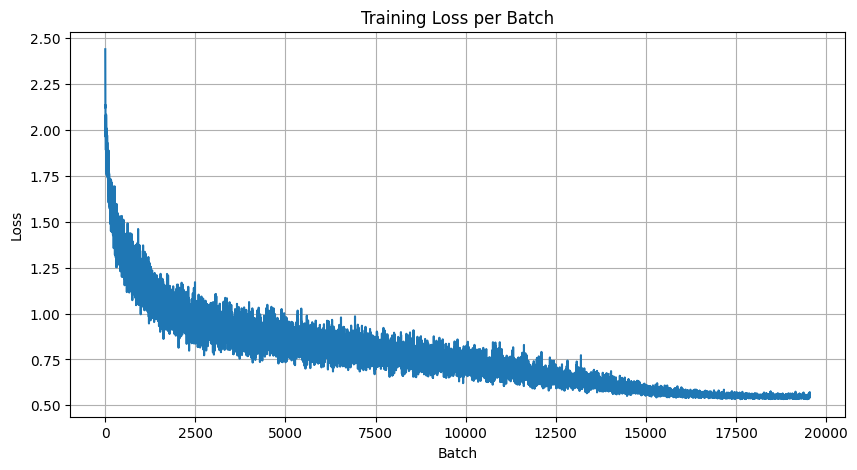

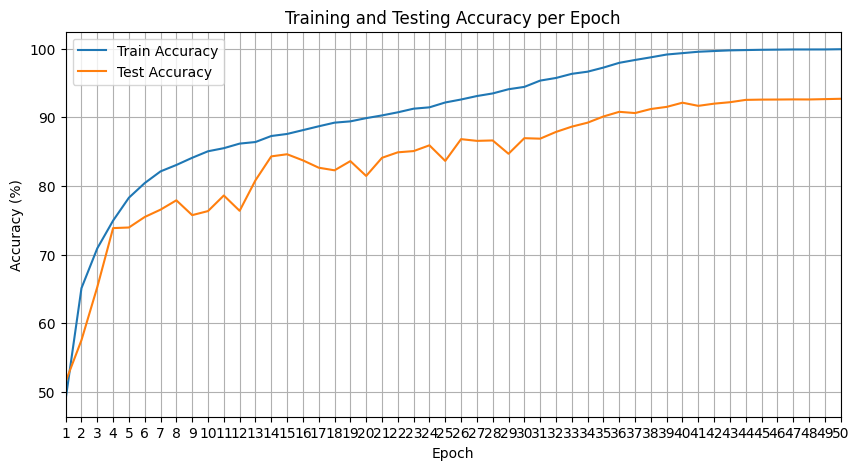

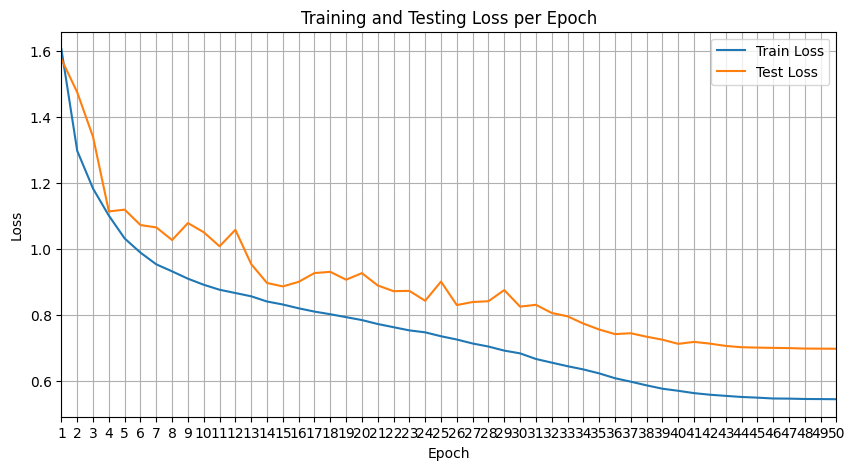

Model weights saved to final_AdaptiveKernelNet_weights.pth


In [ ]:
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes, use_pool=False):
        super().__init__()

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=k, padding=k // 2, bias=False),
                nn.BatchNorm2d(out_channels)
            ) for k in kernel_sizes
        ])

        # Skip Connection
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

        self.fc = nn.Linear(in_channels, len(kernel_sizes))
        self.pool = nn.MaxPool2d(2) if use_pool else nn.Identity()

    def forward(self, x):
        # 1. Save the shortcut (identity or projected)
        identity = self.shortcut(x)

        # 2. Compute branch weights
        m = x.mean(dim=(2, 3))
        a = self.fc(m)
        a = torch.softmax(a, dim=1) #Added 2 April. ensured the branch weights always sum to 1.0.
        # 3. Compute weighted sum of branches
        branch_outputs = torch.stack([branch(x) for branch in self.branches], dim=1)
        a = a.view(a.size(0), a.size(1), 1, 1, 1)
        x_prime = (a * branch_outputs).sum(dim=1)

        # 4. Skip connection
        # allows the gradient to flow through the "shortcut" without being modified by the weights of the branches,
        x_prime += identity

        x_prime = torch.relu(x_prime) #3 April Added

        return self.pool(x_prime)



# ---- Output block ------
# averages each channel, then uses FC layers to output logits

class OutputBlock(nn.Module):
    def __init__(self, in_channels, num_classes=10, hidden_dims=None):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = []

        layers = []
        input_dim = in_channels

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        # x: [batch, c, h, w]
        m = x.mean(dim=(2, 3))
        logits = self.classifier(m)
        return logits



# ----- Full network: combines several intermediate blocks and one output block. ------
class AdaptiveKernelNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = IntermediateBlock(in_channels=3, out_channels=64, kernel_sizes=[3, 5], use_pool=False)
        self.block2 = IntermediateBlock(in_channels=64, out_channels=128, kernel_sizes=[3, 5], use_pool=True)
        self.block3 = IntermediateBlock(in_channels=128, out_channels=256, kernel_sizes=[3, 5], use_pool=True)
        self.block4 = IntermediateBlock(in_channels=256, out_channels=256, kernel_sizes=[3, 5], use_pool=True)

        self.output_block = OutputBlock(in_channels=256, num_classes=10, hidden_dims=[128])

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        logits = self.output_block(x)
        return logits

# ----Train / test-----

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                   # Training mode
    running_loss = 0.0
    correct = 0
    total = 0
    batch_losses = []

    for images, labels in loader:   # one batch at a time
        images = images.to(device, non_blocking=True) # Move to appropriate device
        labels = labels.to(device, non_blocking=True) # Move to appropriate device

        optimizer.zero_grad()       # Zeros the gradients that are stored in the model parameters
        outputs = model(images)     # Use the model to perform the computation. Forward pass
        loss = criterion(outputs, labels) # Compute the loss based on the outputs and labels tensors
        loss.backward()             # backpropagation to compute the gradient of the loss l w.r.t the model parameters
        optimizer.step()            # Do one step of gradient descent, Updates the model parameters based on the gradients stored in them.

        running_loss += loss.item() # Stores the loss for this batch. Could write as running_loss.append(float(l)).
        batch_losses.append(loss.item())

        predictions = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()


    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy, batch_losses


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)   # forward pass through the network. Outputs are raw logits one score per class.

            # Track test loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)   #pick the index of the highest score, i.e the model's predicted class. No need for softmax as just adds to computation.

            total += labels.size(0)   #Counts how many images processed.
            correct += (predictions == labels).sum().item()   #Compares predicted class vs true class for every image in the batch, counts how many match.


    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

#----- Run -----

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 50
model = AdaptiveKernelNet().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Applies softmax internally as part of the loss calculation. 19th April added label_smoothing=0.1
optimizer = optim.SGD(model.parameters(),lr=0.1,momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) # added Cosine annealing smoothly reduces the LR following a cosine curve. Prevents LR being too large late in training and fixes instability seen towards the end of the epoch.

best_acc = 0.0
best_epoch = 0
total_start = time.time()

# Store history for plotting later
history = {
    'batch_loss': [],
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'lr': []
}

for epoch in range(epochs):
    epoch_start = time.time()

    train_loss, train_acc, batch_losses = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']

    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start

    if test_acc > best_acc:
        best_acc = test_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_AdaptiveKernelNet_weights.pth')

    # Store for graphs
    history['batch_loss'].extend(batch_losses)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    print(
        f"Epoch {epoch+1:>3}/{epochs} | "
        f"LR: {current_lr:.5f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}% | "
        f"Best: {best_acc:.2f}% | "
        f"Epoch Time: {epoch_time:.1f}s | "
        f"Total Time: {total_time/60:.1f}m"
    )

print(f"\nTraining complete. Best test accuracy: {best_acc:.2f}% at epoch {best_epoch}")

# ---Plots---
# Plot 1: training loss for each batch
plt.figure(figsize=(10, 5))
plt.plot(history['batch_loss'])
plt.title('Training Loss per Batch')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Plot 2: training accuracy and testing accuracy for each epoch
epoch_nums = range(1, len(history['train_acc']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_acc'], label='Train Accuracy')
plt.plot(epoch_nums, history['test_acc'], label='Test Accuracy')
plt.title('Training and Testing Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.xticks(range(0, epochs+1, 5))
plt.xlim(1, len(history['train_acc']))
plt.show()

# Plot 3: training loss and testing loss for each epoch
plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_loss'], label='Train Loss')
plt.plot(epoch_nums, history['test_loss'], label='Test Loss')
plt.title('Training and Testing Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.xticks(range(0, epochs+1, 5))
plt.xlim(1, len(history['train_loss']))
plt.show()

# Save the model weights once training is finished
torch.save(model.state_dict(), 'final_AdaptiveKernelNet_weights.pth')
print("Model weights saved to final_AdaptiveKernelNet_weights.pth")

# JItter Transform - Reduced train accuracy


In [ ]:
# The standard CIFAR-10 training augmentation pipeline
train_transform = transforms.Compose([
    # Step A: Pad the image by 4 pixels then take a random 32x32 crop.
    # This simulates the object being in different positions.
    transforms.RandomCrop(32, padding=4),

    # Step B: Flip the image horizontally with a 50% chance.
    # A car facing left is still a car.
    transforms.RandomHorizontalFlip(p=0.5),

    # Step C: Optional - slight rotation (CIFAR-10 is small, so keep it subtle)
    # Removed because performance dropped. Likely rotation can cut off meaningful pixels at the edges and hurt more than it helps.
    # transforms.RandomRotation(15),

    # Randomly varies colour properties, helping the model generalise across lighting conditions.
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),

    # Step D: Convert to PyTorch Tensor
    transforms.ToTensor(),

    # Step E: Normalize with CIFAR-10 specific Mean and Std Dev
    # These constants are calculated across the entire dataset.
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# Test transform should NOT have random crops or flips
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010))
])

# -----------------------------
# 2. Load Datasets
# -----------------------------

train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=train_transform)
test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)


100%|██████████| 170M/170M [00:14<00:00, 12.1MB/s]


Epoch   1/50 | LR: 0.04995 | Train Loss: 1.7943 | Train Acc: 39.04% | Test Loss: 1.4946 | Test Acc: 52.05% | Best: 52.05% | Epoch Time: 69.8s | Total Time: 1.2m
Epoch   2/50 | LR: 0.04980 | Train Loss: 1.4914 | Train Acc: 54.78% | Test Loss: 1.3625 | Test Acc: 60.10% | Best: 60.10% | Epoch Time: 74.1s | Total Time: 2.4m
Epoch   3/50 | LR: 0.04956 | Train Loss: 1.3557 | Train Acc: 61.80% | Test Loss: 1.1665 | Test Acc: 71.14% | Best: 71.14% | Epoch Time: 73.6s | Total Time: 3.6m
Epoch   4/50 | LR: 0.04921 | Train Loss: 1.2660 | Train Acc: 66.73% | Test Loss: 1.1744 | Test Acc: 70.07% | Best: 71.14% | Epoch Time: 73.7s | Total Time: 4.9m
Epoch   5/50 | LR: 0.04878 | Train Loss: 1.1903 | Train Acc: 70.33% | Test Loss: 1.0538 | Test Acc: 76.66% | Best: 76.66% | Epoch Time: 73.1s | Total Time: 6.1m
Epoch   6/50 | LR: 0.04824 | Train Loss: 1.1290 | Train Acc: 73.69% | Test Loss: 1.0025 | Test Acc: 78.86% | Best: 78.86% | Epoch Time: 73.3s | Total Time: 7.3m
Epoch   7/50 | LR: 0.04762 | Train

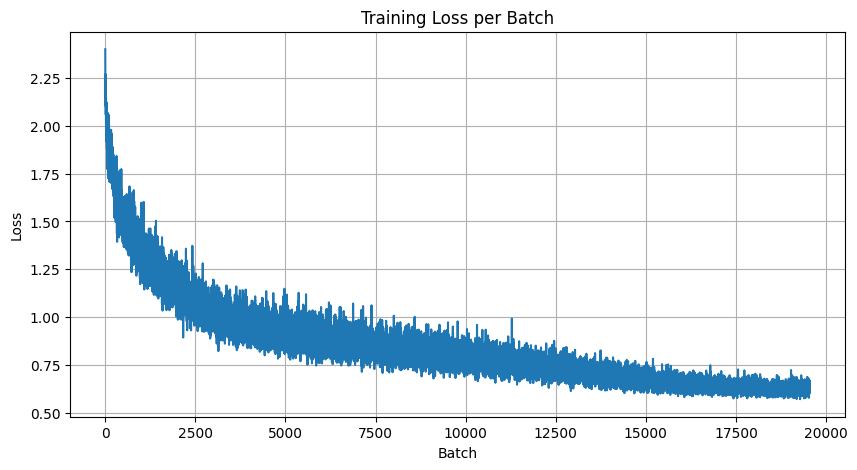

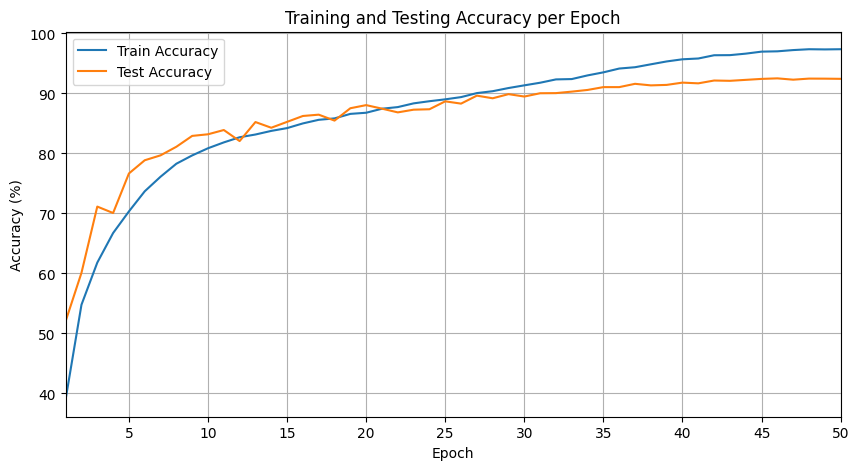

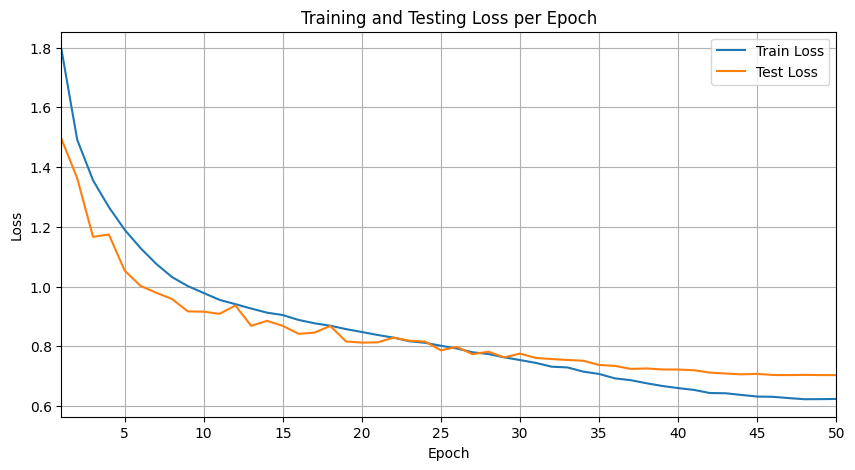

Model weights saved to no skip final_AdaptiveKernelNet_weights.pth
Last epoch data saved to no_skip_last_epoch_output.json


In [ ]:
class IntermediateBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_sizes, use_pool=False):
        super().__init__()

        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=k, padding=k // 2, bias=False),
                nn.BatchNorm2d(out_channels)
            ) for k in kernel_sizes
        ])
        self.dropout = nn.Dropout2d(0.1)
        self.post_bn = nn.BatchNorm2d(out_channels)  #normalize after branch fusion
        self.fc = nn.Linear(in_channels, len(kernel_sizes))
        self.pool = nn.MaxPool2d(2) if use_pool else nn.Identity()

    def forward(self, x):

        # 2. Compute branch weights
        m = x.mean(dim=(2, 3))
        a = self.fc(m)
        a = torch.softmax(a, dim=1) #Added 2 April. ensured the branch weights always sum to 1.0. Prevents exploding gradients for high learning rates.
        # 3. Compute weighted sum of branches
        branch_outputs = torch.stack([branch(x) for branch in self.branches], dim=1)
        a = a.view(a.size(0), a.size(1), 1, 1, 1)
        x_prime = (a * branch_outputs).sum(dim=1)
        x_prime = self.post_bn(x_prime) # 24 April Added. weighted sum normalized stabilize combined output because removed skip connection.
        x_prime = torch.relu(x_prime) #3 April Added
        x_prime = self.dropout(x_prime)

        return self.pool(x_prime)



# ---- Output block ------
# averages each channel, then uses FC layers to output logits

class OutputBlock(nn.Module):
    def __init__(self, in_channels, num_classes=10, hidden_dims=None):
        super().__init__()

        if hidden_dims is None:
            hidden_dims = []

        layers = []
        input_dim = in_channels

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            input_dim = hidden_dim

        layers.append(nn.Linear(input_dim, num_classes))
        self.classifier = nn.Sequential(*layers)

    def forward(self, x):
        # x: [batch, c, h, w]
        m = x.mean(dim=(2, 3))
        logits = self.classifier(m)
        return logits



# ----- Full network: combines several intermediate blocks and one output block. ------
class AdaptiveKernelNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.block1 = IntermediateBlock(in_channels=3, out_channels=64, kernel_sizes=[3, 5], use_pool=False)
        self.block2 = IntermediateBlock(in_channels=64, out_channels=128, kernel_sizes=[3, 5], use_pool=True)
        self.block3 = IntermediateBlock(in_channels=128, out_channels=256, kernel_sizes=[3, 5], use_pool=True)
        self.block4 = IntermediateBlock(in_channels=256, out_channels=256, kernel_sizes=[3, 5], use_pool=True)

        self.output_block = OutputBlock(in_channels=256, num_classes=10, hidden_dims=[128])

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x)
        logits = self.output_block(x)
        return logits

# ----Train / test-----

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()                   # Training mode
    running_loss = 0.0
    correct = 0
    total = 0
    batch_losses = []

    for images, labels in loader:   # one batch at a time
        images = images.to(device, non_blocking=True) # Move to appropriate device
        labels = labels.to(device, non_blocking=True) # Move to appropriate device

        optimizer.zero_grad()       # Zeros the gradients that are stored in the model parameters
        outputs = model(images)     # Use the model to perform the computation. Forward pass
        loss = criterion(outputs, labels) # Compute the loss based on the outputs and labels tensors
        loss.backward()             # backpropagation to compute the gradient of the loss l w.r.t the model parameters
        optimizer.step()            # Do one step of gradient descent, Updates the model parameters based on the gradients stored in them.

        running_loss += loss.item() # Stores the loss for this batch. Could write as running_loss.append(float(l)).
        batch_losses.append(loss.item())

        predictions = outputs.argmax(dim=1)
        total += labels.size(0)
        correct += (predictions == labels).sum().item()


    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy, batch_losses


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)   # forward pass through the network. Outputs are raw logits one score per class.

            # Track test loss
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            predictions = outputs.argmax(dim=1)   #pick the index of the highest score, i.e the model's predicted class. No need for softmax as just adds to computation.

            total += labels.size(0)   #Counts how many images processed.
            correct += (predictions == labels).sum().item()   #Compares predicted class vs true class for every image in the batch, counts how many match.


    avg_loss = running_loss / len(loader)
    accuracy = 100.0 * correct / total
    return avg_loss, accuracy

#----- Run ----- changed lr from 0.1 to 0.05

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epochs = 50
model = AdaptiveKernelNet().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Applies softmax internally as part of the loss calculation. 19th April added label_smoothing=0.1
optimizer = optim.SGD(model.parameters(),lr=0.05,momentum=0.9, weight_decay=5e-4, nesterov=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) # added Cosine annealing smoothly reduces the LR following a cosine curve. Prevents LR being too large late in training and fixes instability seen towards the end of the epoch.

best_acc = 0.0
best_epoch = 0
total_start = time.time()

# Store history for plotting later
history = {
    'batch_loss': [],
    'train_loss': [],
    'train_acc': [],
    'test_loss': [],
    'test_acc': [],
    'lr': []
}

for epoch in range(epochs):
    epoch_start = time.time()

    train_loss, train_acc, batch_losses = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss,  test_acc  = evaluate(model, test_loader, criterion, device)
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']


    epoch_time = time.time() - epoch_start
    total_time = time.time() - total_start

    if test_acc > best_acc:
        best_acc = test_acc
        best_epoch = epoch + 1
        torch.save(model.state_dict(), 'best_AdaptiveKernelNet_weights.pth')

    # Store for graphs
    history['batch_loss'].extend(batch_losses)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)
    history['lr'].append(current_lr)

    print(
        f"Epoch {epoch+1:>3}/{epochs} | "
        f"LR: {current_lr:.5f} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.2f}% | "
        f"Best: {best_acc:.2f}% | "
        f"Epoch Time: {epoch_time:.1f}s | "
        f"Total Time: {total_time/60:.1f}m"
    )

print(f"\nTraining complete. Best test accuracy: {best_acc:.2f}% at epoch {best_epoch}")

# ---Plots---
# Plot 1: training loss for each batch
plt.figure(figsize=(10, 5))
plt.plot(history['batch_loss'])
plt.title('Training Loss per Batch')
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Plot 2: training accuracy and testing accuracy for each epoch
epoch_nums = range(1, len(history['train_acc']) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_acc'], label='Train Accuracy')
plt.plot(epoch_nums, history['test_acc'], label='Test Accuracy')
plt.title('Training and Testing Accuracy per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
# plt.xticks(list(epoch_nums))
plt.xticks(range(0, epochs+1, 5))
plt.xlim(1, len(history['train_acc']))
plt.show()

# Plot 3: training loss and testing loss for each epoch
plt.figure(figsize=(10, 5))
plt.plot(epoch_nums, history['train_loss'], label='Train Loss')
plt.plot(epoch_nums, history['test_loss'], label='Test Loss')
plt.title('Training and Testing Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
# plt.xticks(list(epoch_nums))
plt.xticks(range(0, epochs+1, 5))
plt.xlim(1, len(history['train_loss']))
plt.show()

# Save the model weights once training is finished
torch.save(model.state_dict(), 'Dropout_noskip_final_AdaptiveKernelNet_weights.pth')
print("Model weights saved to no skip final_AdaptiveKernelNet_weights.pth")


# Save raw output of last epoch
last_epoch_data = {
    'train_loss': history['train_loss'][-1],
    'train_acc': history['train_acc'][-1],
    'test_loss': history['test_loss'][-1],
    'test_acc': history['test_acc'][-1],
    'lr': history['lr'][-1],
    'epoch': epochs
}

import json
with open('last_epoch_output.json', 'w') as f:
    json.dump(last_epoch_data, f, indent=4)

print("Last epoch data saved to no_skip_last_epoch_output.json")